In [68]:
import os

import anndata
import plotnine as p
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [85]:
h5ad_dir = "scvi_output"
for filename in os.listdir(h5ad_dir):
    if filename.endswith(".h5ad"):
        filepath = os.path.join(h5ad_dir, filename)
        adata_tmp = anndata.io.read_h5ad(filepath)
        print(f"File: {filename}")
        print(adata_tmp)

File: variational_all_donors_20250618_055850.h5ad
AnnData object with n_obs × n_vars = 1058909 × 10
    obs: 'mapped_reference_assembly', 'alignment_software', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Country', 'nCount_RNA', 'nFeature_RNA', 'Ethnicity_Selfreported', 'TCR_VDJdb', 'TCRa_V_gene', 'TCRa_D_gene', 'TCRa_J_gene', 'TCRa_C_gene', 'TCRb_V_gene', 'TCRb_D_gene', 'TCRb_J_gene', 'TCRb_C_gene', 'TCR_Clonality', 'TCR_Clone_ID', 'BCR_VDJ_V_call

In [164]:
obs = anndata.io.read_h5ad('scvi_output/variational_all_donors_20250618_055850.h5ad', backed = 'r').obs

In [181]:
obs

,mapped_reference_assembly,alignment_software,library_uuid,assay_ontology_term_id,library_starting_quantity,is_primary_data,cell_type_ontology_term_id,author_cell_type,sample_uuid,tissue_ontology_term_id,...,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,_scvi_batch,_scvi_labels,is_held_out,donor_split
index,,,,,,,,,,,,,,,,,,,,,
CCGGGATAGTCCTCCT-SG_B1_L1,GRCh38,DRAGEN RNA v3.8.4,925ed908-cb3d-4eeb-8db9-cf8967de971d,EFO:0009900,40000 cells,True,CL:0000939,CD16+_NK,daa1ba19-8d79-4a87-99fb-f21d3b8401b9,UBERON:0000178,...,Homo sapiens,male,blood,Singaporean Chinese,57-year-old stage,8f#L6|1m%y,288,0,False,train
CCGGTAGCACAGACTT-SG_B1_L1,GRCh38,DRAGEN RNA v3.8.4,925ed908-cb3d-4eeb-8db9-cf8967de971d,EFO:0009900,40000 cells,True,CL:0000939,CD16+_NK,daa1ba19-8d79-4a87-99fb-f21d3b8401b9,UBERON:0000178,...,Homo sapiens,male,blood,Singaporean Chinese,57-year-old stage,1!@Oln-=Ry,288,0,False,train
TAGCCGGGTCACCTAA-SG_B1_L1,GRCh38,DRAGEN RNA v3.8.4,925ed908-cb3d-4eeb-8db9-cf8967de971d,EFO:0009900,40000 cells,True,CL:0001054,CD14+_Monocyte,daa1ba19-8d79-4a87-99fb-f21d3b8401b9,UBERON:0000178,...,Homo sapiens,male,blood,Singaporean Chinese,57-year-old stage,$4Ix88Mx``,288,0,False,train
CAGCGACTCCACTCCA-SG_B1_L1,GRCh38,DRAGEN RNA v3.8.4,925ed908-cb3d-4eeb-8db9-cf8967de971d,EFO:0009900,40000 cells,True,CL:0001054,CD14+_Monocyte,daa1ba19-8d79-4a87-99fb-f21d3b8401b9,UBERON:0000178,...,Homo sapiens,male,blood,Singaporean Chinese,57-year-old stage,Fh#f=&fIt|,288,0,False,train
CACAGTAGTGTCCTCT-SG_B1_L1,GRCh38,DRAGEN RNA v3.8.4,925ed908-cb3d-4eeb-8db9-cf8967de971d,EFO:0009900,40000 cells,True,CL:0000909,CD8+_T_GZMK+,daa1ba19-8d79-4a87-99fb-f21d3b8401b9,UBERON:0000178,...,Homo sapiens,male,blood,Singaporean Chinese,57-year-old stage,F2zRd4T{v|,288,0,False,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACTGCGCACTTAAGC-KR_B12_L2,GRCh38,DRAGEN RNA v3.8.4,f7b36e3c-39e1-4aac-88ce-12f31ef4bf33,EFO:0009900,40000 cells,True,CL:0000787,IGHMhi_memory_B,d8e5835f-da4d-4ae9-a748-bf9d853a836e,UBERON:0000178,...,Homo sapiens,male,blood,European,23-year-old stage,8kFzEti%uk,284,0,False,train
GTTACAGCACACTGCG-KR_B12_L2,GRCh38,DRAGEN RNA v3.8.4,f7b36e3c-39e1-4aac-88ce-12f31ef4bf33,EFO:0009900,40000 cells,True,CL:0002396,CD16+_Monocyte,d8e5835f-da4d-4ae9-a748-bf9d853a836e,UBERON:0000178,...,Homo sapiens,male,blood,European,23-year-old stage,gD~fsGpbL7,284,0,False,train
ACACTGAAGTGTTGAA-KR_B12_L2,GRCh38,DRAGEN RNA v3.8.4,f7b36e3c-39e1-4aac-88ce-12f31ef4bf33,EFO:0009900,40000 cells,True,CL:0001054,CD14+_Monocyte,d8e5835f-da4d-4ae9-a748-bf9d853a836e,UBERON:0000178,...,Homo sapiens,male,blood,European,23-year-old stage,jT>vfA^4`s,284,0,False,train


In [168]:
obs.columns

Index(['mapped_reference_assembly', 'alignment_software', 'library_uuid',
       'assay_ontology_term_id', 'library_starting_quantity',
       'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type',
       'sample_uuid', 'tissue_ontology_term_id',
       'development_stage_ontology_term_id', 'sample_derivation_process',
       'donor_BMI_at_collection', 'suspension_derivation_process',
       'suspension_enriched_cell_types', 'suspension_percent_cell_viability',
       'suspension_uuid', 'suspension_type', 'donor_id',
       'self_reported_ethnicity_ontology_term_id',
       'donor_living_at_sample_collection', 'organism_ontology_term_id',
       'disease_ontology_term_id', 'sex_ontology_term_id', 'Country',
       'nCount_RNA', 'nFeature_RNA', 'Ethnicity_Selfreported', 'TCR_VDJdb',
       'TCRa_V_gene', 'TCRa_D_gene', 'TCRa_J_gene', 'TCRa_C_gene',
       'TCRb_V_gene', 'TCRb_D_gene', 'TCRb_J_gene', 'TCRb_C_gene',
       'TCR_Clonality', 'TCR_Clone_ID', 'BCR_VDJ_V_call', '

In [172]:
obs['assay_ontology_term_id']

index
CCGGGATAGTCCTCCT-SG_B1_L1     EFO:0009900
CCGGTAGCACAGACTT-SG_B1_L1     EFO:0009900
TAGCCGGGTCACCTAA-SG_B1_L1     EFO:0009900
CAGCGACTCCACTCCA-SG_B1_L1     EFO:0009900
CACAGTAGTGTCCTCT-SG_B1_L1     EFO:0009900
                                 ...     
GACTGCGCACTTAAGC-KR_B12_L2    EFO:0009900
GTTACAGCACACTGCG-KR_B12_L2    EFO:0009900
ACACTGAAGTGTTGAA-KR_B12_L2    EFO:0009900
GATCGTACATCGACGC-KR_B12_L2    EFO:0009900
TTCTTAGAGCTAGGCA-KR_B12_L2    EFO:0009900
Name: assay_ontology_term_id, Length: 1058909, dtype: category
Categories (1, object): ['EFO:0009900']

In [201]:
adata = anndata.io.read_h5ad('scvi_output/batch_embeddings_20250618_055850.h5ad')

In [202]:
# Perform PCA
pca = PCA(n_components = 5)
pcs = pca.fit_transform(adata.X)

# Save PCs to obs
for i in range(1, 6):
    adata.obs[f'PC{i}'] = pcs[:, i - 1]

In [203]:
def extract_center(donor_id):
    parts = donor_id.split('_')
    if len(parts) >= 3:
        center = parts[1]
        return center.replace('HEL', 'GIS')
    else:
        return 'LONZA'

adata.obs['center'] = adata.obs['donor_id'].apply(extract_center)

adata = adata[adata.obs['center'] != 'LONZA', :].copy()

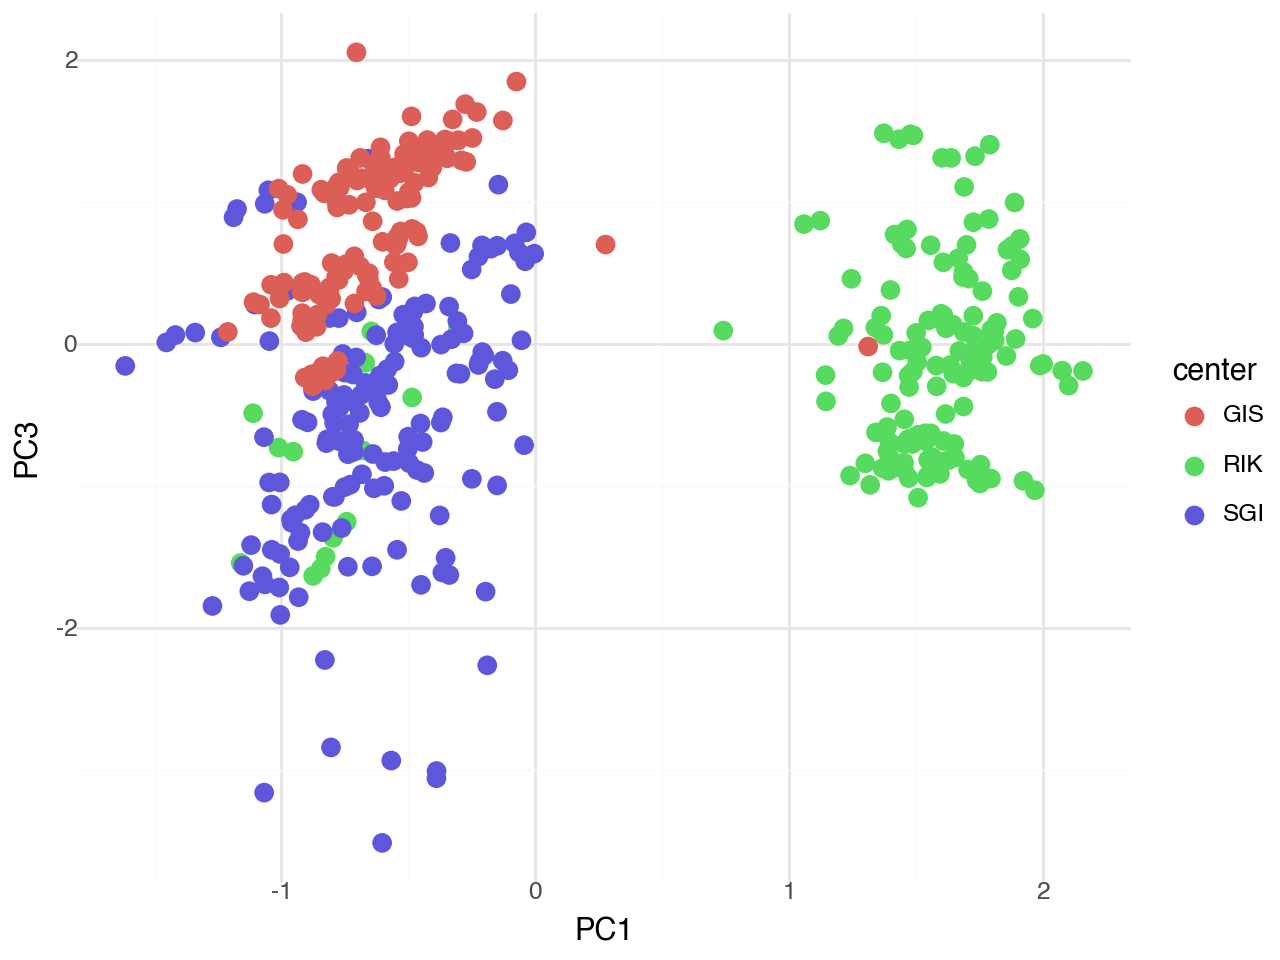

In [204]:
(
    p.ggplot(adata.obs)
    + p.aes(x = 'PC1', y = 'PC3', color = 'center')
    + p.geom_point(size = 3)
    + p.theme_minimal()
)

In [205]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(adata.X)

# Save t-SNE results to obs
adata.obs['TSNE1'] = tsne_results[:, 0]
adata.obs['TSNE2'] = tsne_results[:, 1]

/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul


/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 5 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure3A


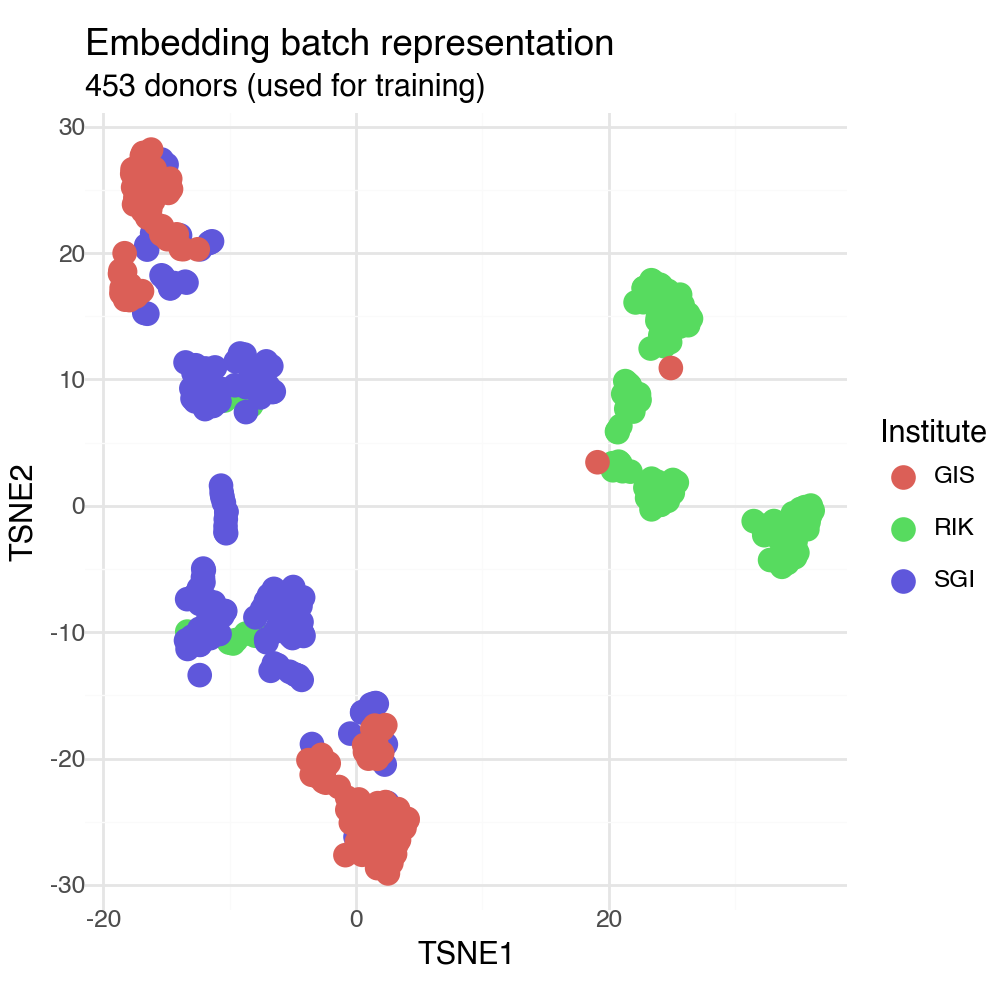

In [206]:
p_ = (
    p.ggplot(adata.obs)
    + p.aes(x = 'TSNE1', y = 'TSNE2', color = 'center')
    + p.geom_point(size = 4)
    + p.coord_equal()
    + p.theme_minimal()
    + p.theme(figure_size = (5, 5))
    + p.labs(
        title = 'Embedding batch representation',
        subtitle = '453 donors (used for training)',
        color = 'Institute'
    )
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure3A', dpi = 300)

p_

In [154]:
adata.shape

(458, 5)

In [207]:
adata = anndata.io.read_h5ad('scvi_output/variational_batch_embeddings_20250618_055850.h5ad')

In [208]:
# Perform PCA
pca = PCA(n_components = 5)
pcs = pca.fit_transform(adata.X)

# Save PCs to obs
for i in range(1, 6):
    adata.obs[f'PC{i}'] = pcs[:, i - 1]

def extract_center(donor_id):
    parts = donor_id.split('_')
    if len(parts) >= 3:
        return parts[1]
    else:
        return 'LONZA'

adata.obs['center'] = adata.obs['donor_id'].apply(extract_center)

In [209]:
def extract_center(donor_id):
    parts = donor_id.split('_')
    if len(parts) >= 3:
        center = parts[1]
        return center.replace('HEL', 'GIS')
    else:
        return 'LONZA'

adata.obs['center'] = adata.obs['donor_id'].apply(extract_center)

adata = adata[adata.obs['center'] != 'LONZA', :].copy()

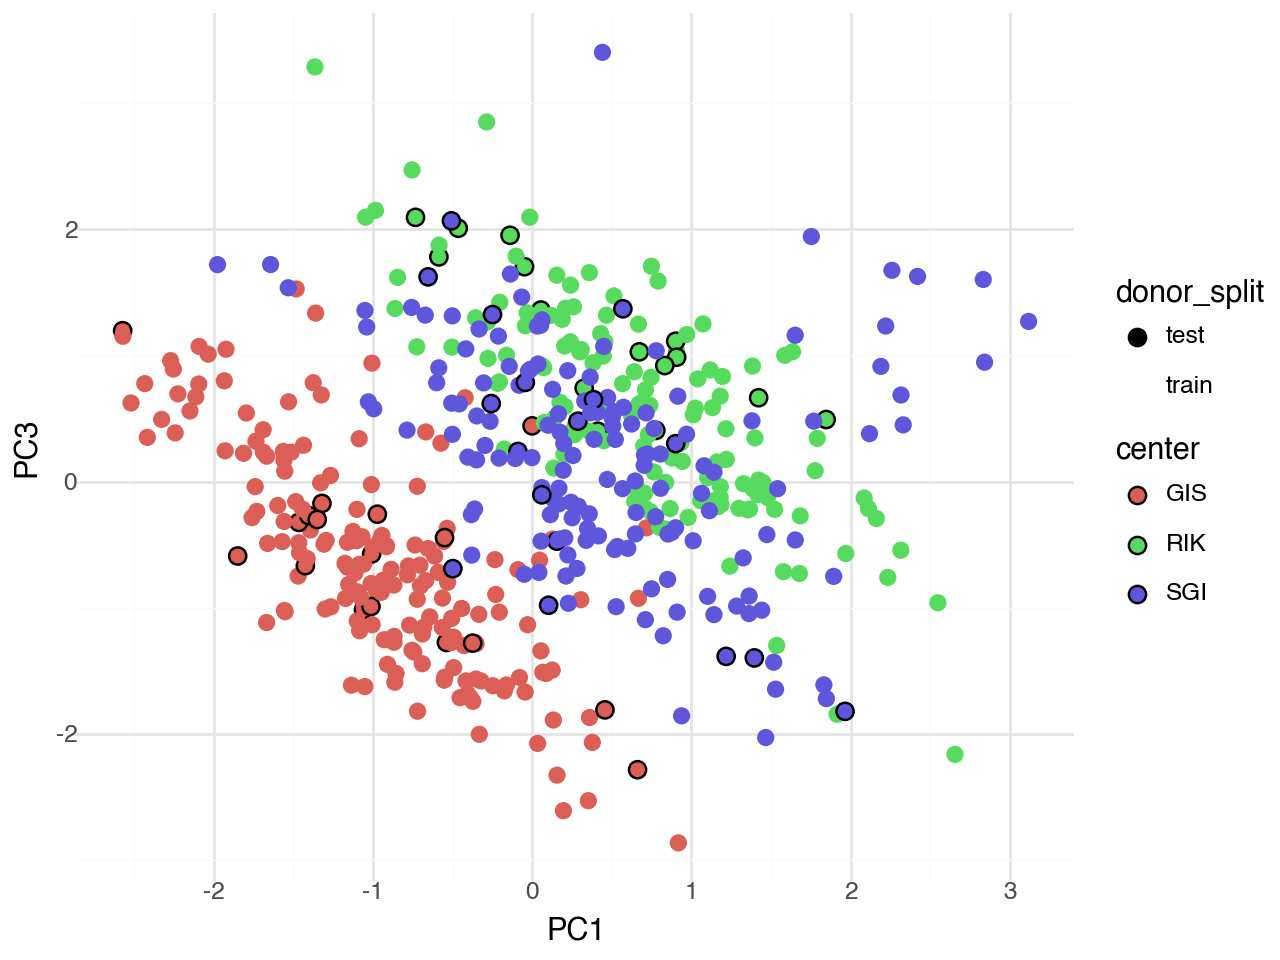

In [210]:
(
    p.ggplot(adata.obs)
    + p.aes(x = 'PC1', y = 'PC3', fill = 'center', color = 'donor_split')
    + p.geom_point(size = 3)
    + p.scale_color_manual({'train': 'none', 'test': 'black'})
    + p.theme_minimal()
)

In [211]:
from sklearn.manifold import TSNE

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(adata.X)

# Save t-SNE results to obs
adata.obs['TSNE1'] = tsne_results[:, 0]
adata.obs['TSNE2'] = tsne_results[:, 1]

/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul


/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure3B


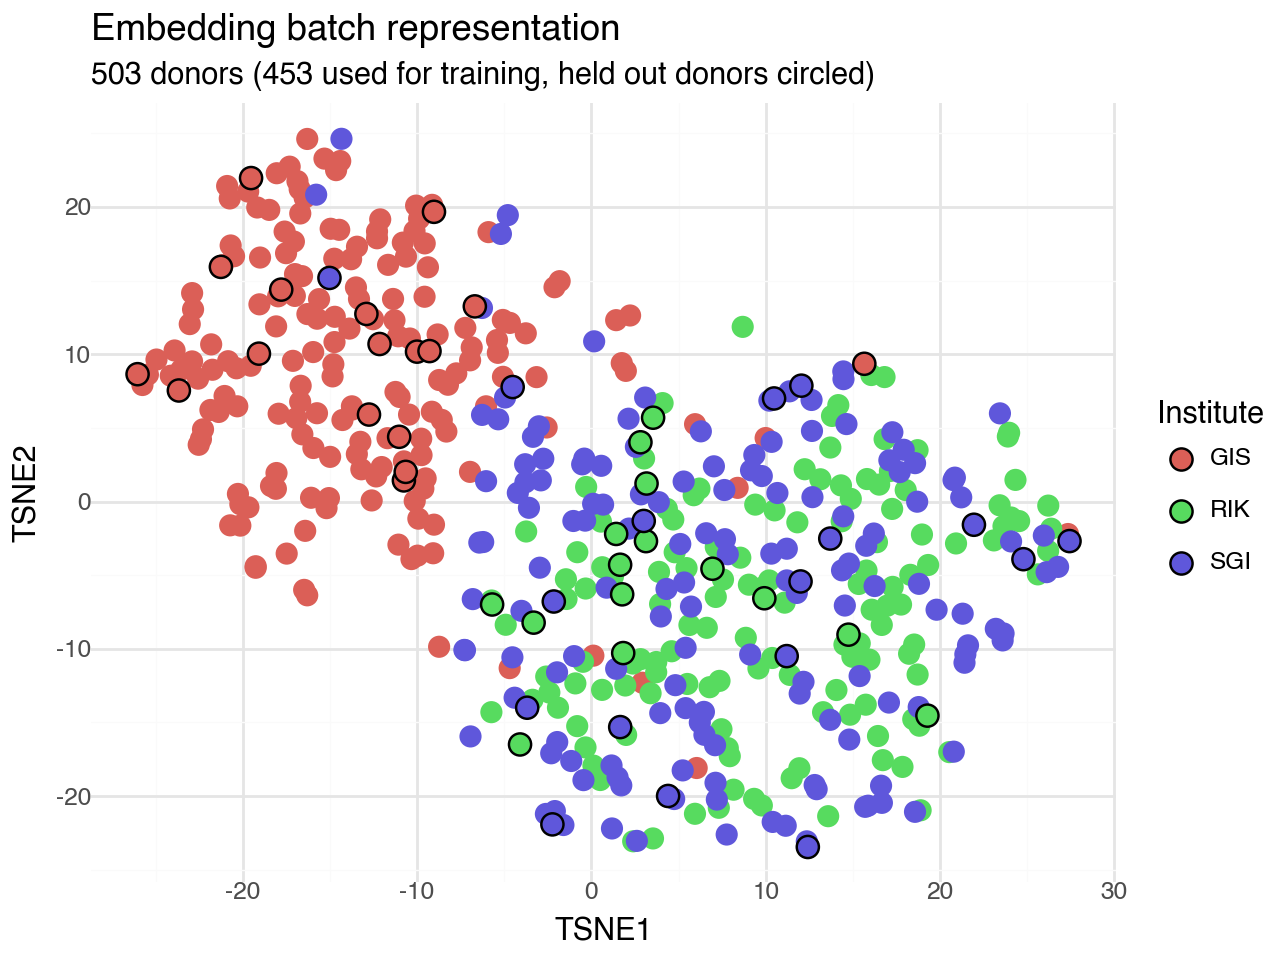

In [212]:
p_ = (
    p.ggplot(adata.obs)
    + p.aes(x = 'TSNE1', y = 'TSNE2', fill = 'center')
    + p.geom_point(size = 4, color = 'none')
    + p.geom_point(size = 4, color = 'black', data = adata.obs.query('donor_split == "test"'))
    + p.theme_minimal()
    + p.labs(fill = 'Institute')
    + p.labs(
        title = 'Embedding batch representation',
        subtitle = '503 donors (453 used for training, held out donors circled)',
        color = 'Institute'
    )
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure3B', dpi = 300)

p_

In [103]:
# Run openTSNE on all latent representation files
import anndata
from openTSNE import TSNE
import numpy as np

# List of latent files to process
latent_files = [
    'scvi_output/latent_variational_20250618_055850.h5ad',
    'scvi_output/latent_embedding_20250618_055850.h5ad', 
    'scvi_output/latent_one-hot_20250618_055850.h5ad'
]

for file_path in latent_files:
    print(f"Processing {file_path}...")
    
    # Read the file
    adata = anndata.read_h5ad(file_path)
    print(f"Data shape: {adata.shape}")
    
    # Run openTSNE
    tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
    tsne_embedding = tsne.fit(adata.X)
    
    # Save TSNE coordinates to obs (cast to numpy arrays)
    adata.obs['TSNE1'] = np.array(tsne_embedding[:, 0])
    adata.obs['TSNE2'] = np.array(tsne_embedding[:, 1])
    
    # Save back to file
    adata.write_h5ad(file_path)
    print(f"Saved TSNE embeddings to {file_path}")
    print()

Processing scvi_output/latent_variational_20250618_055850.h5ad...
Data shape: (100000, 10)


/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul


Saved TSNE embeddings to scvi_output/latent_variational_20250618_055850.h5ad

Processing scvi_output/latent_embedding_20250618_055850.h5ad...
Data shape: (100000, 10)


/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul


Saved TSNE embeddings to scvi_output/latent_embedding_20250618_055850.h5ad

Processing scvi_output/latent_one-hot_20250618_055850.h5ad...
Data shape: (100000, 10)


/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
/Users/val/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul


Saved TSNE embeddings to scvi_output/latent_one-hot_20250618_055850.h5ad



/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 3 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure1.png


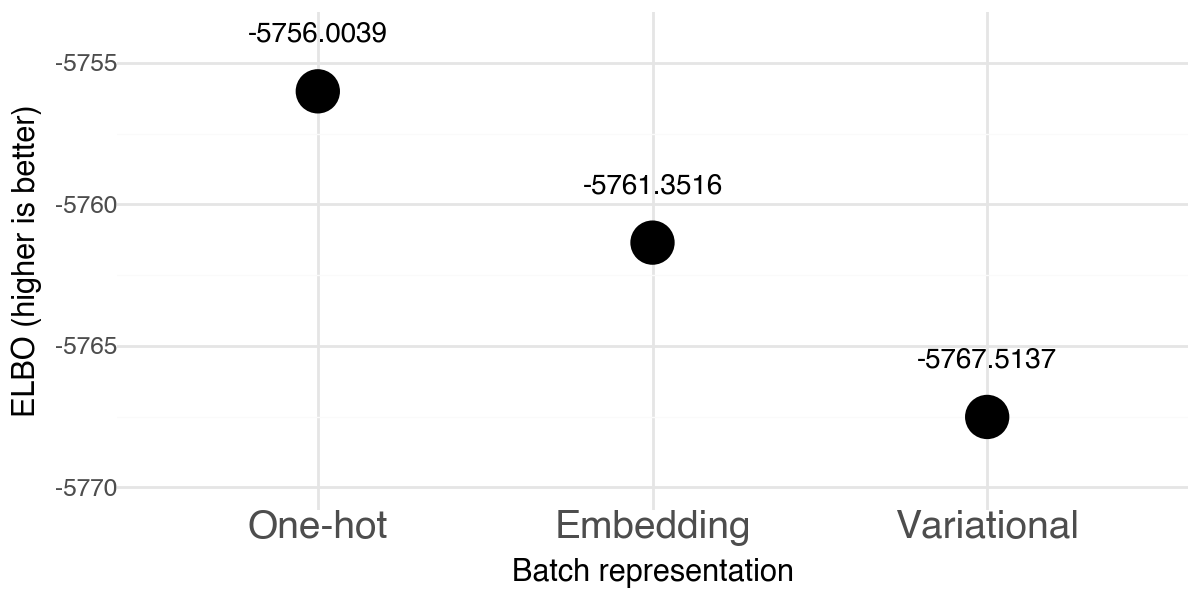

In [101]:
# Create ELBO comparison using points with y-axis zoomed to relevant range
import pandas as pd

# ELBO data from the log
elbo_data = pd.DataFrame({
    'Model': ['One-hot', 'Embedding', 'Variational'],
    'ELBO': [-5756.0039, -5761.3516, -5767.5137]
})

p_ = (
    p.ggplot(elbo_data)
    + p.aes(x='Model', y='ELBO')
    + p.geom_point(size = 8)
    + p.geom_text(p.aes(label='ELBO'), nudge_y=2, size=10)
    + p.scale_x_discrete(limits=['One-hot', 'Embedding', 'Variational'])
    + p.scale_y_continuous(limits=[-5770, -5754])
    + p.theme_minimal()
    + p.labs(
        x = 'Batch representation',
        y='ELBO (higher is better)'
    )
    + p.theme(
        figure_size=(6, 3), 
        axis_text_x=p.element_text(size=14),
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure1.png', dpi = 300)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure2A


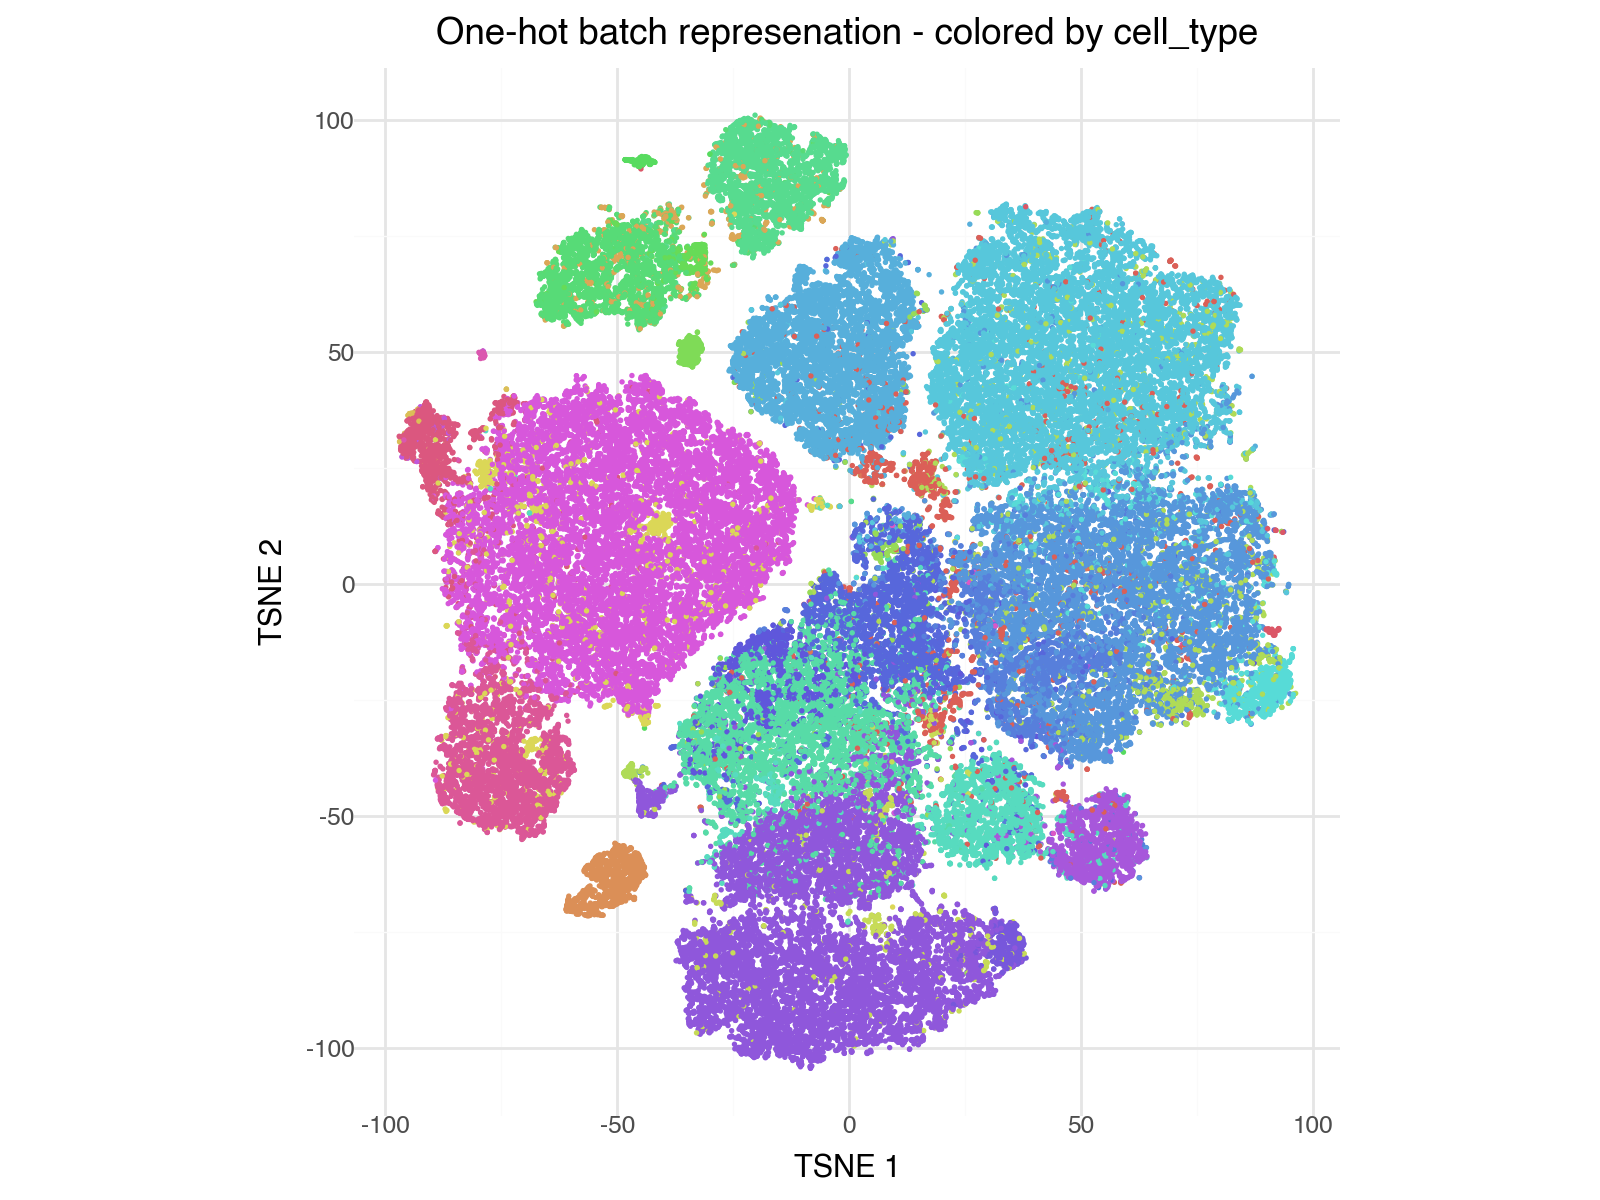

In [130]:
adata = anndata.read_h5ad('scvi_output/latent_one-hot_20250618_055850.h5ad')

p_ = (
    p.ggplot(adata.obs)
    + p.aes(x='TSNE1', y='TSNE2', color='cell_type')
    + p.geom_point(size=0.1)
    + p.coord_equal()
    + p.theme_minimal()
    + p.labs(title='One-hot batch represenation - colored by cell_type',
             x='TSNE 1', y='TSNE 2')
    + p.theme(figure_size=(8, 6), legend_position='none')
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure2A', dpi = 300)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure2B


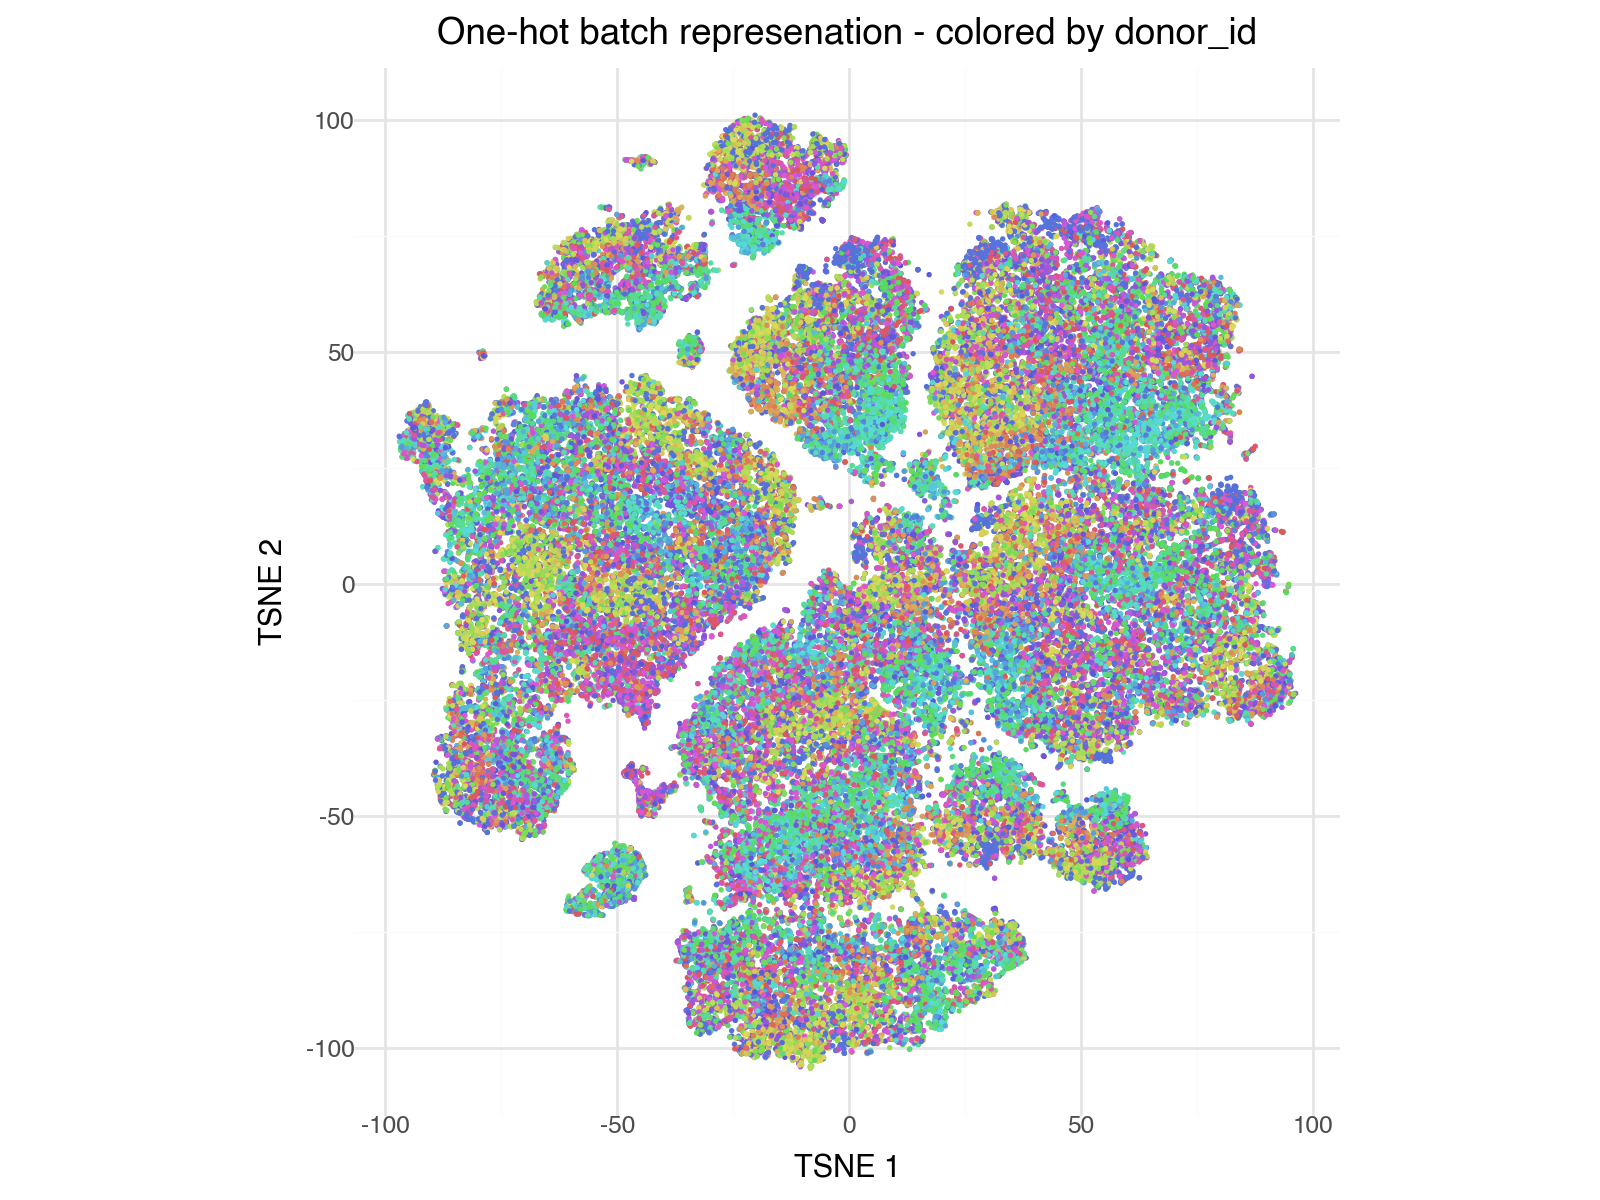

In [131]:
adata = anndata.read_h5ad('scvi_output/latent_one-hot_20250618_055850.h5ad')

p_ = (
    p.ggplot(adata.obs)
    + p.aes(x='TSNE1', y='TSNE2', color='donor_id')
    + p.geom_point(size=0.1)
    + p.coord_equal()
    + p.theme_minimal()
    + p.labs(title='One-hot batch represenation - colored by donor_id',
             x='TSNE 1', y='TSNE 2')
    + p.theme(figure_size=(8, 6), legend_position='none')
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure2B', dpi = 300)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure2C


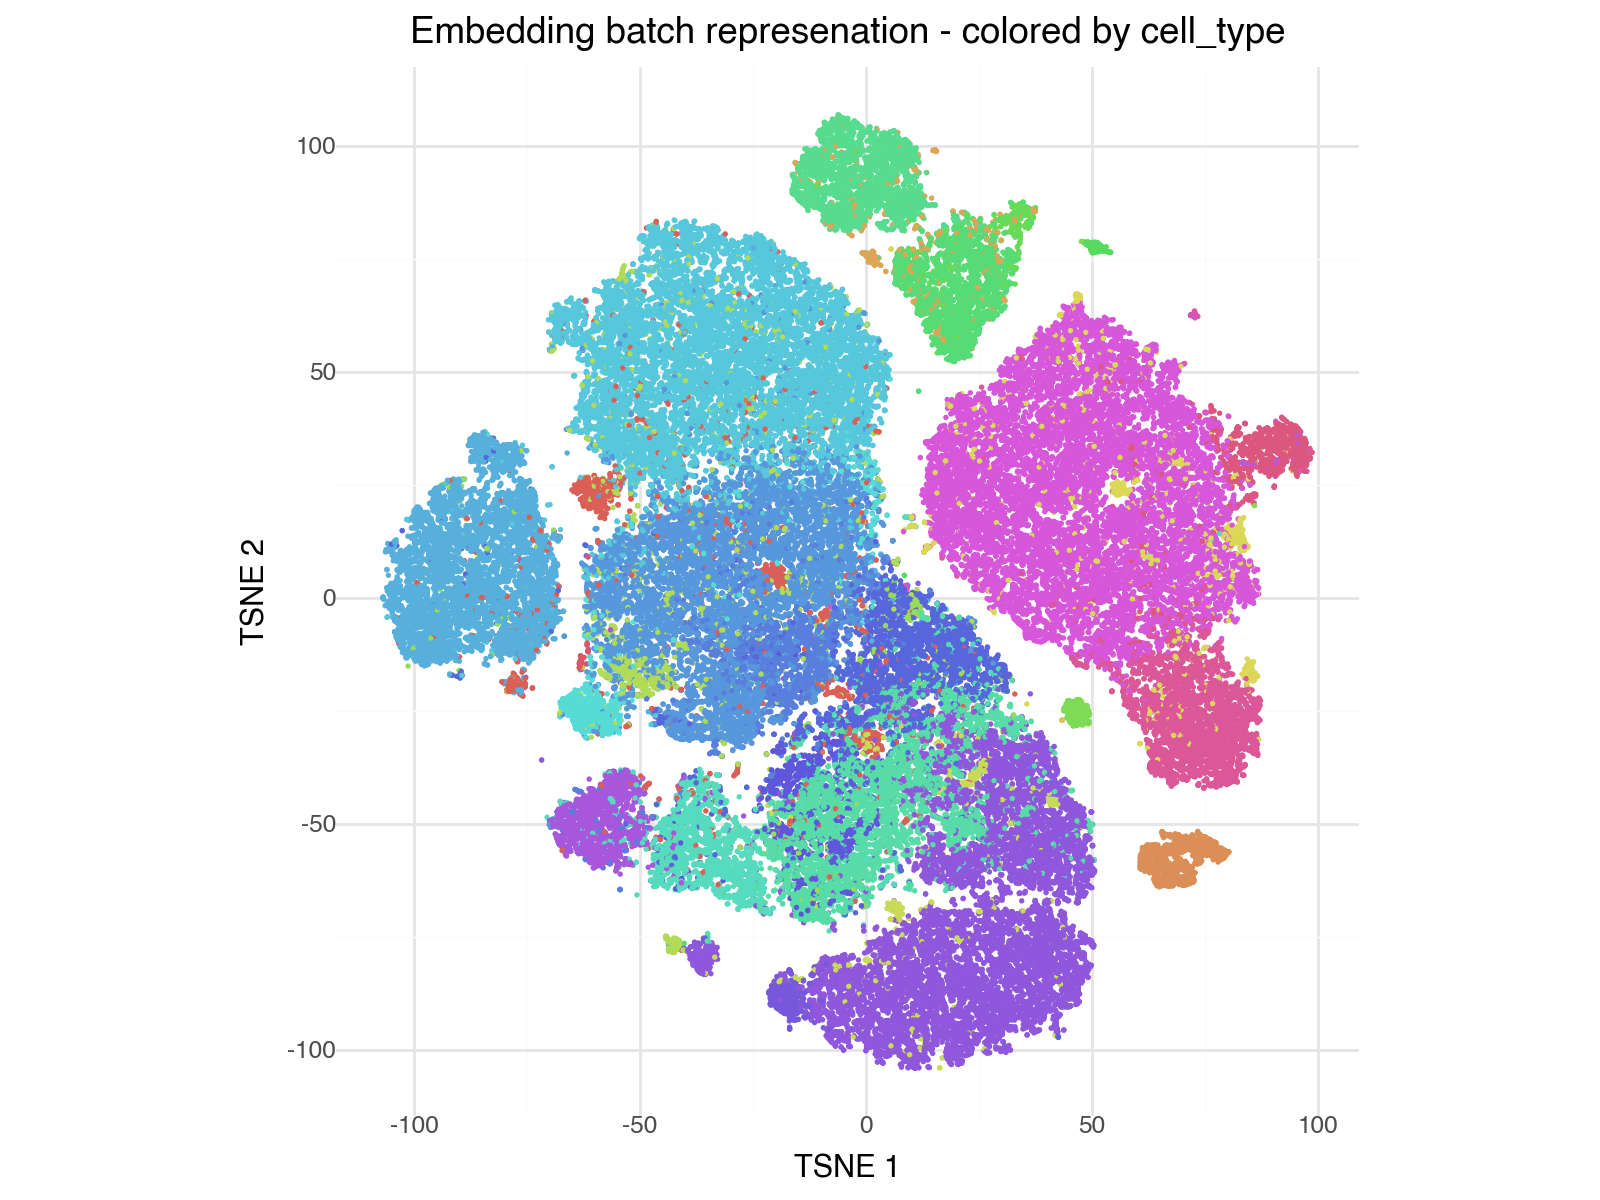

In [132]:
adata = anndata.read_h5ad('scvi_output/latent_embedding_20250618_055850.h5ad')

p_ = (
    p.ggplot(adata.obs)
    + p.aes(x='TSNE1', y='TSNE2', color='cell_type')
    + p.geom_point(size=0.1)
    + p.coord_equal()
    + p.theme_minimal()
    + p.labs(title='Embedding batch represenation - colored by cell_type',
             x='TSNE 1', y='TSNE 2')
    + p.theme(figure_size=(8, 6), legend_position='none')
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure2C', dpi = 300)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure2D


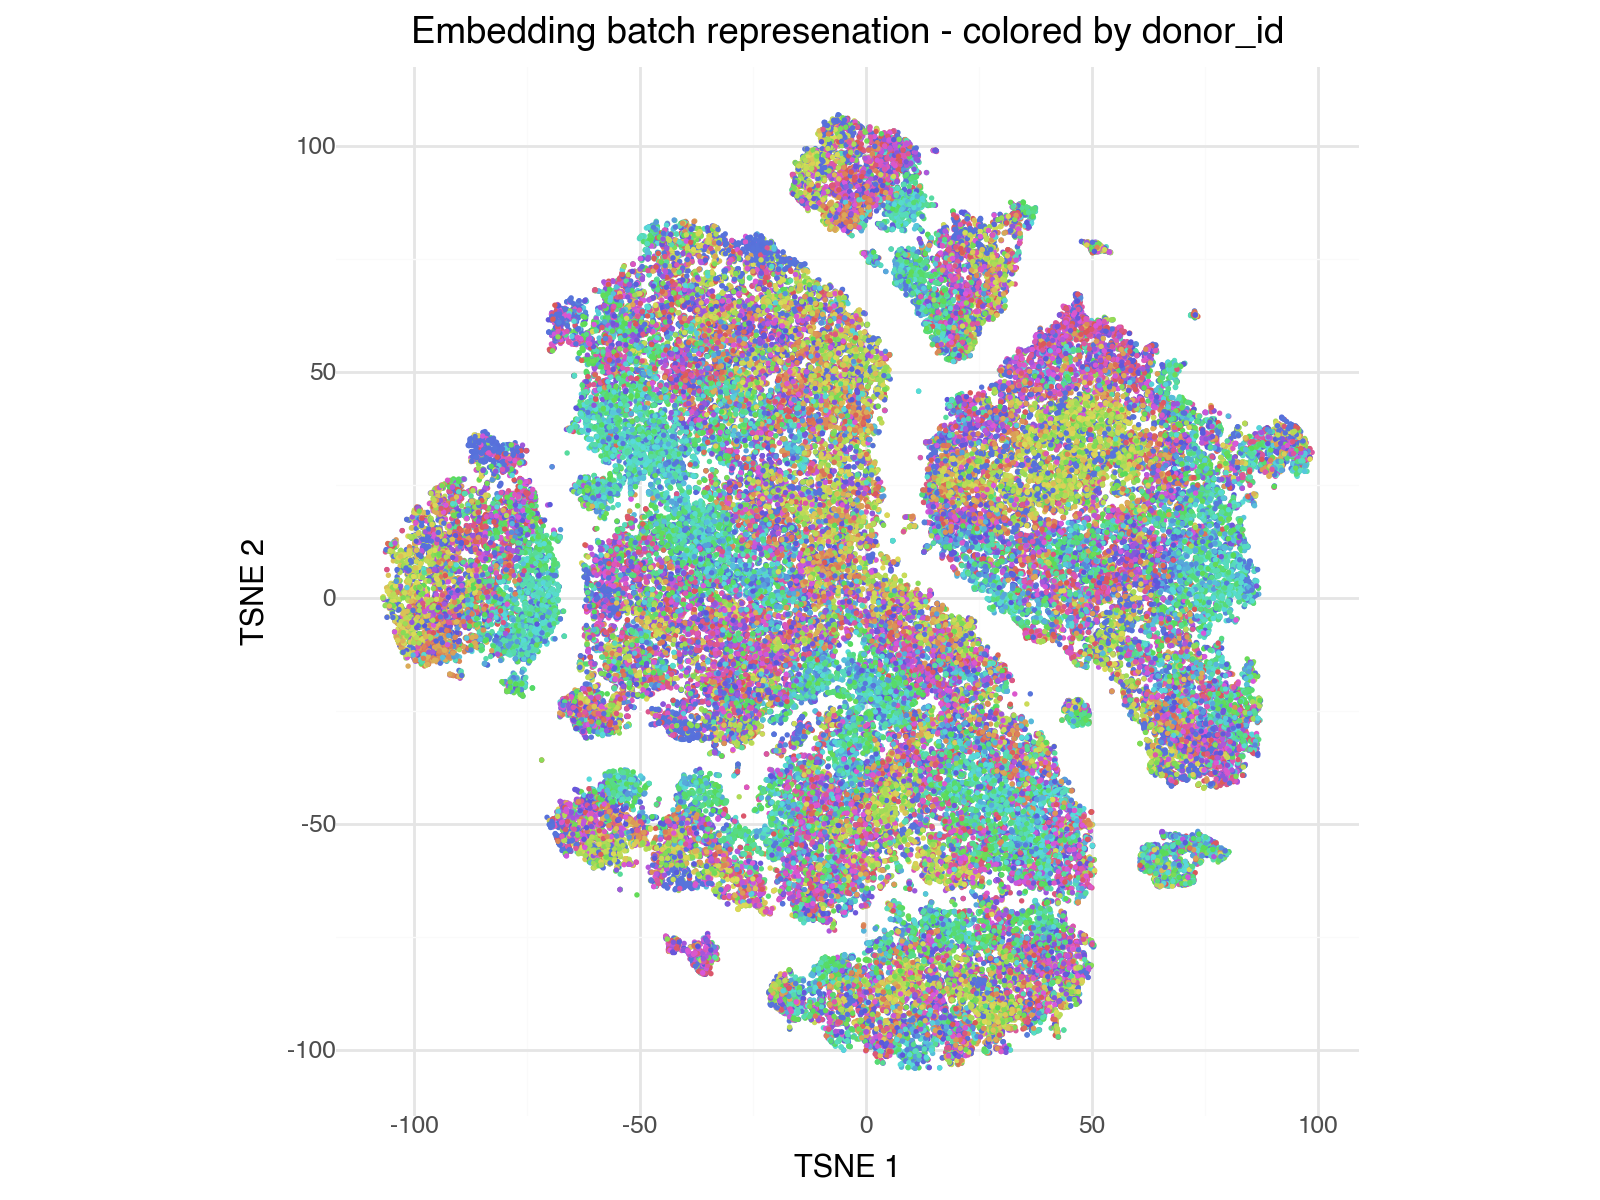

In [133]:
adata = anndata.read_h5ad('scvi_output/latent_embedding_20250618_055850.h5ad')

p_ = (
    p.ggplot(adata.obs)
    + p.aes(x='TSNE1', y='TSNE2', color='donor_id')
    + p.geom_point(size=0.1)
    + p.coord_equal()
    + p.theme_minimal()
    + p.labs(title='Embedding batch represenation - colored by donor_id',
             x='TSNE 1', y='TSNE 2')
    + p.theme(figure_size=(8, 6), legend_position='none')
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure2D', dpi = 300)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure2E


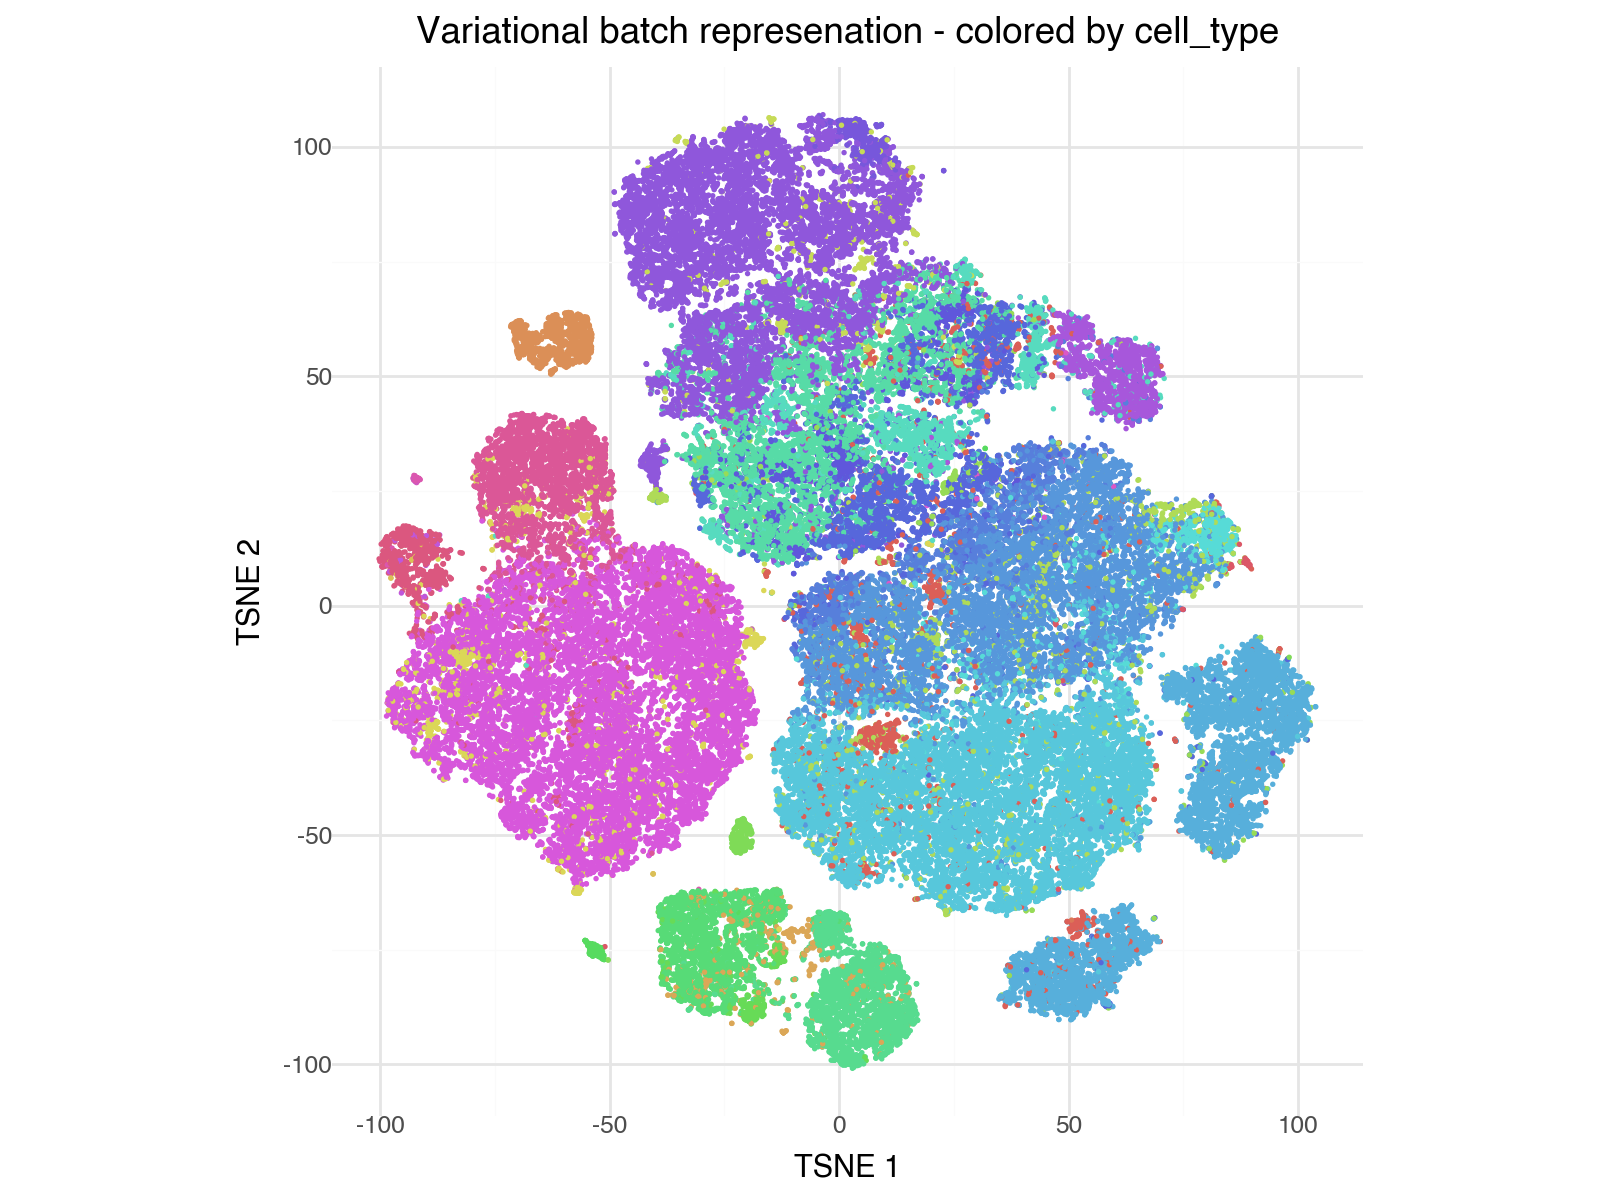

In [134]:
adata = anndata.read_h5ad('scvi_output/latent_variational_20250618_055850.h5ad')

p_ = (
    p.ggplot(adata.obs)
    + p.aes(x='TSNE1', y='TSNE2', color='cell_type')
    + p.geom_point(size=0.1)
    + p.coord_equal()
    + p.theme_minimal()
    + p.labs(title='Variational batch represenation - colored by cell_type',
             x='TSNE 1', y='TSNE 2')
    + p.theme(figure_size=(8, 6), legend_position='none')
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure2E', dpi = 300)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure2F


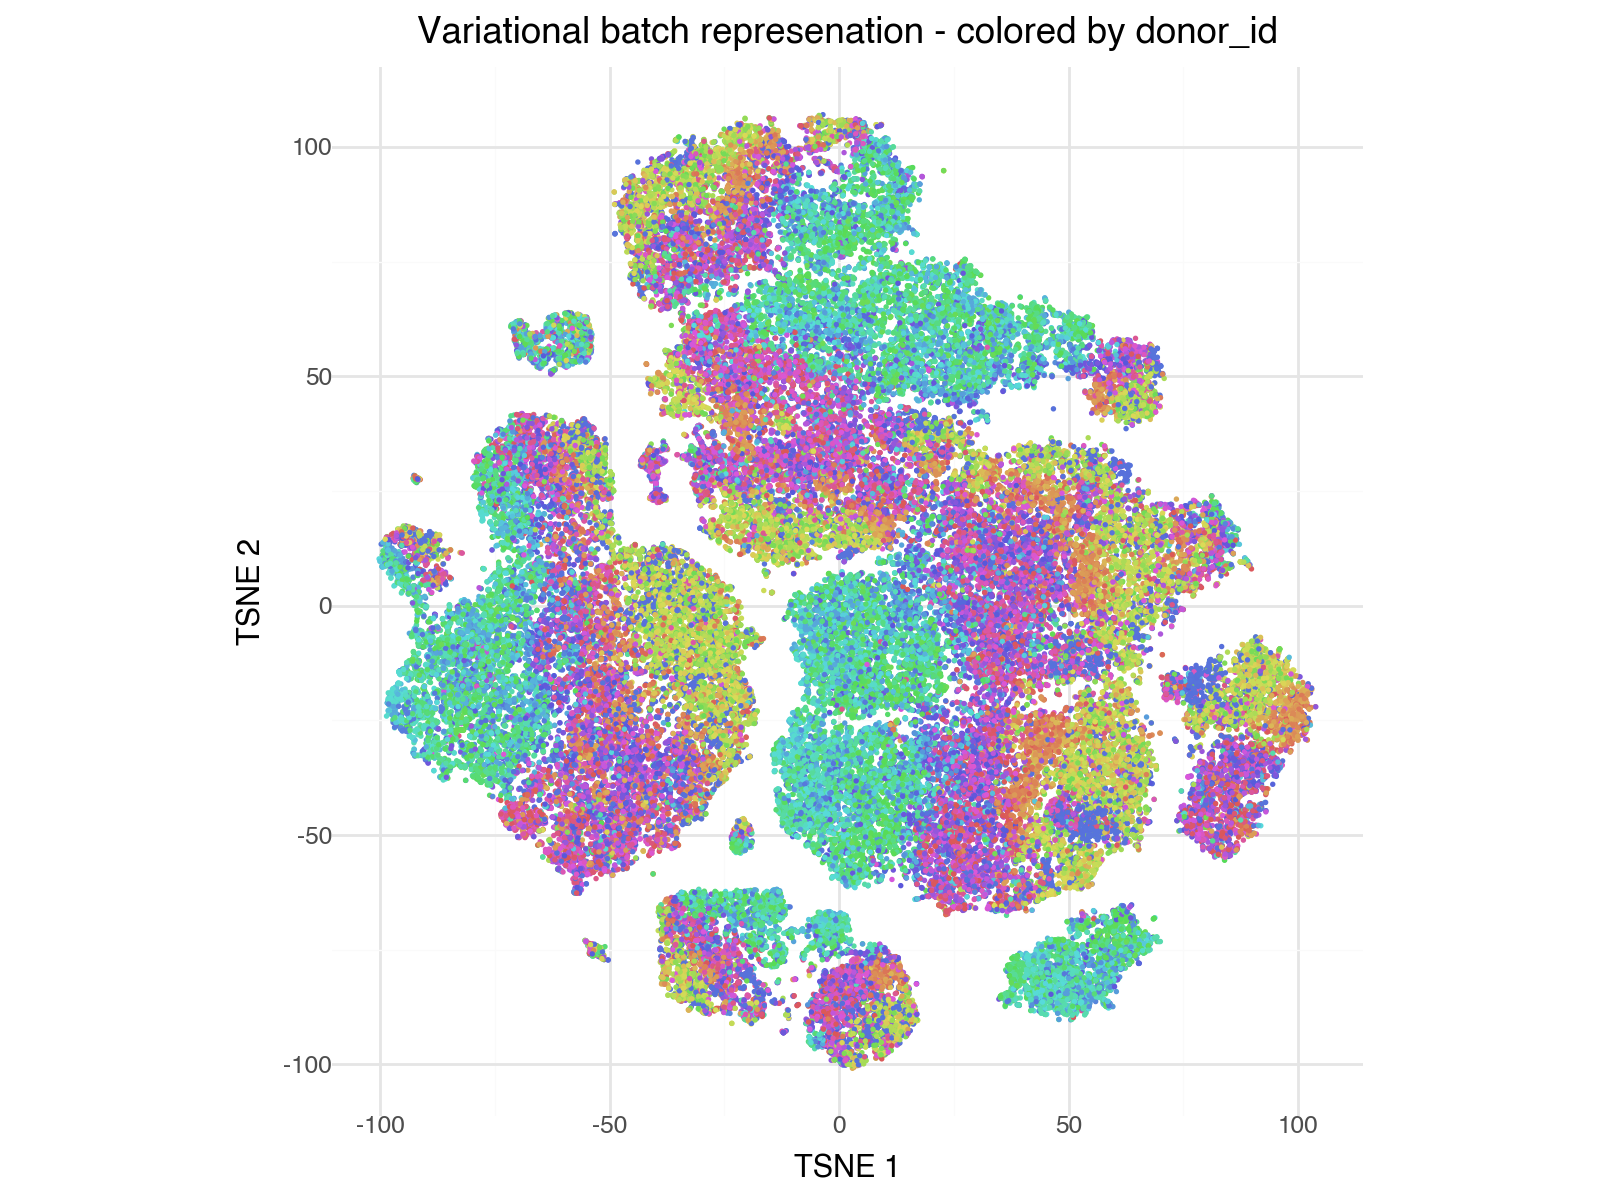

In [135]:
adata = anndata.read_h5ad('scvi_output/latent_variational_20250618_055850.h5ad')

p_ = (
    p.ggplot(adata.obs)
    + p.aes(x='TSNE1', y='TSNE2', color='donor_id')
    + p.geom_point(size=0.1)
    + p.coord_equal()
    + p.theme_minimal()
    + p.labs(title='Variational batch represenation - colored by donor_id',
             x='TSNE 1', y='TSNE 2')
    + p.theme(figure_size=(8, 6), legend_position='none')
    + p.theme(
        panel_background=p.element_rect(fill='white', color = 'none'),
        plot_background=p.element_rect(fill='white', color = 'none')
    )
)

p_.save('Figure2F', dpi = 300)

p_